# 04 Waddington Potential Prediction

Illustrative sketches for fitting a Waddington-like developmental potential to morphological trajectories, then using that landscape to reason about new observations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# FIG_DIR = Path("/Users/nick/Projects/data/morphseq/results/20260528/fishcaster_figures")
FIG_DIR = Path('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/fishcaster')
FIG_DIR.mkdir(parents=True, exist_ok=True)

BIFURCATION_FEATURE1 = -0.94
START_POS = (-1.55, 0.52)
N_STEPS = 150
DT = 0.025
DIFFUSION = 0.025
MOBILITY = 1.0
TRAJECTORY_SMOOTHING_SIGMA = 8.0
ENDPOINT_DENSITY_SMOOTHING_SIGMA = 1.45
POTENTIAL_DISPLAY_CLIP_PERCENTILE = 94
POTENTIAL_DISPLAY_COMPRESSION = 6.0


def strip_plot_chrome(ax):
    ax.set(title="", xlabel="", ylabel="")
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()


def strip_colorbar_chrome(cbar):
    cbar.set_label("")
    cbar.ax.tick_params(
        which="both",
        left=False,
        right=False,
        labelleft=False,
        labelright=False,
    )


def compress_potential_for_plot(
    U,
    clip_percentile=POTENTIAL_DISPLAY_CLIP_PERCENTILE,
    compression=POTENTIAL_DISPLAY_COMPRESSION,
):
    """Compress high potential walls so valley topology remains visible in figures."""
    U0 = np.asarray(U, dtype=float) - np.nanmin(U)
    upper = np.nanpercentile(U0, clip_percentile)
    if not np.isfinite(upper) or upper <= 0:
        return U0
    U0 = np.clip(U0, 0, upper)
    return np.log1p(compression * U0 / upper)


## Simulated Potential Surface

The axes are morphology features rather than time. Developmental directionality is implicit: trajectories move downhill across the fitted potential, while the valley geometry confines them and eventually bifurcates into two morphological fates.

In [2]:
def simulate_potential_surface(
    feature1_lim=(-3.0, 3.0),
    feature2_lim=(-2.4, 2.4),
    n_grid=360,
    split_feature1=BIFURCATION_FEATURE1,
    transition_width=0.38,
    branch_strength=1.55,
    directionality_slope=0.8,
    feature1_curvature=0.035,
    branch_bias=0.0,
):
    """Return a 2D Waddington-like potential with one valley splitting into two.

    Parameters tune the shape of the cartoon landscape rather than a physical model.
    Both coordinates are morphology features; developmental time is implicit in downhill motion.
    """
    feature1 = np.linspace(*feature1_lim, n_grid)
    feature2 = np.linspace(*feature2_lim, n_grid)
    F1, F2 = np.meshgrid(feature1, feature2)

    sigmoid = 1 / (1 + np.exp(-(F1 - split_feature1) / transition_width))
    bifurcation = branch_strength * (2 * sigmoid - 1)

    branch_potential = 0.25 * F2**4 - 0.5 * bifurcation * F2**2
    directionality_potential = -directionality_slope * F1 + feature1_curvature * F1**2
    asymmetric_nudge = branch_bias * sigmoid * F2

    U = branch_potential + directionality_potential + asymmetric_nudge
    U -= U.min()

    return {
        "feature1": feature1,
        "feature2": feature2,
        "F1": F1,
        "F2": F2,
        "U": U,
        "bifurcation": bifurcation,
        "split_feature1": split_feature1,
        "directionality_slope": directionality_slope,
    }


surface = simulate_potential_surface(split_feature1=BIFURCATION_FEATURE1)
surface["U"].shape, surface["U"].min(), surface["U"].max()


((360, 360), 0.0, 18.119597515349795)

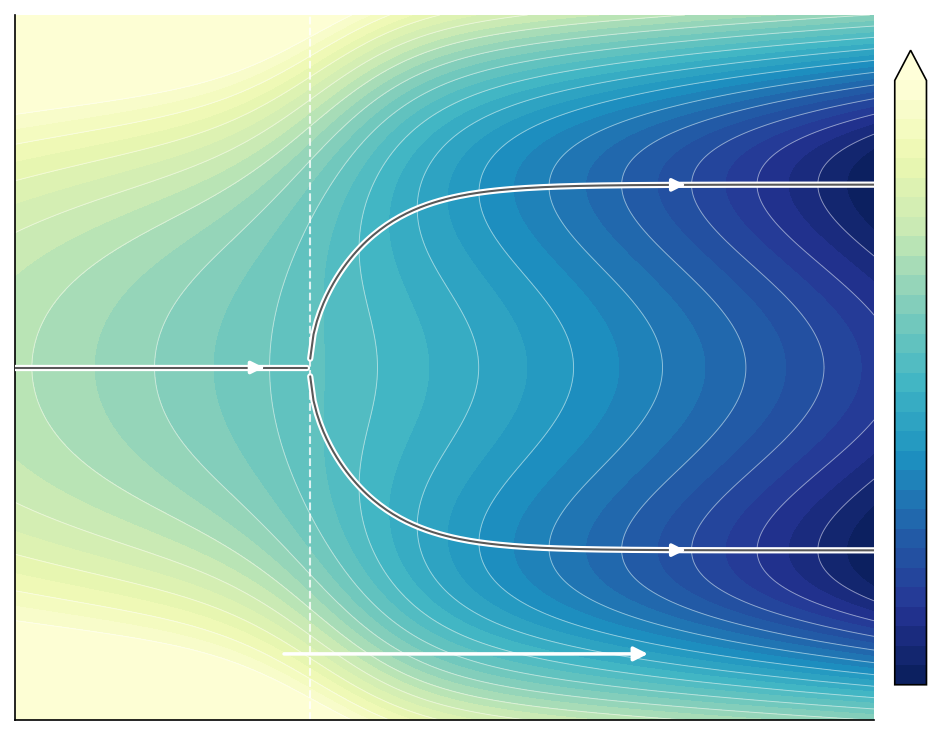

In [3]:
def branch_centerlines(feature1, split_feature1=BIFURCATION_FEATURE1, transition_width=0.38, branch_strength=1.55):
    sigmoid = 1 / (1 + np.exp(-(feature1 - split_feature1) / transition_width))
    bifurcation = branch_strength * (2 * sigmoid - 1)
    branch_y = np.sqrt(np.clip(bifurcation, 0, None))
    return branch_y


def add_path_arrow(ax, x, y, idx, color="white"):
    ax.annotate(
        "",
        xy=(x[idx + 1], y[idx + 1]),
        xytext=(x[idx], y[idx]),
        arrowprops={"arrowstyle": "-|>", "color": color, "lw": 1.8, "mutation_scale": 12},
        zorder=6,
    )


F1 = surface["F1"]
F2 = surface["F2"]
U = surface["U"]
U_plot = compress_potential_for_plot(U)
split_feature1 = surface["split_feature1"]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
levels = np.linspace(U_plot.min(), U_plot.max(), 32)
filled = ax.contourf(F1, F2, U_plot, levels=levels, cmap="YlGnBu_r", extend="max")
ax.contour(F1, F2, U_plot, levels=levels[::2], colors="white", linewidths=0.45, alpha=0.5)

feature1_path = np.linspace(F1.min(), F1.max(), 260)
feature2_branch = branch_centerlines(feature1_path, split_feature1=split_feature1)
pre = feature1_path <= split_feature1
post = feature1_path >= split_feature1

ax.plot(feature1_path[pre], np.zeros(pre.sum()), color="white", lw=3.0, solid_capstyle="round", zorder=5)
ax.plot(feature1_path[pre], np.zeros(pre.sum()), color="black", lw=1.0, alpha=0.65, solid_capstyle="round", zorder=6)

for sign in (1, -1):
    feature2 = sign * feature2_branch[post]
    ax.plot(feature1_path[post], feature2, color="white", lw=3.0, solid_capstyle="round", zorder=5)
    ax.plot(feature1_path[post], feature2, color="black", lw=1.0, alpha=0.65, solid_capstyle="round", zorder=6)
    add_path_arrow(ax, feature1_path[post], feature2, idx=112)

add_path_arrow(ax, feature1_path[pre], np.zeros(pre.sum()), idx=74)
ax.axvline(split_feature1, color="white", lw=1.0, ls="--", alpha=0.8)
ax.annotate(
    "",
    xy=(1.45, -1.95),
    xytext=(-1.15, -1.95),
    color="white",
    ha="center",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "white", "lw": 1.7, "mutation_scale": 14},
    zorder=7,
)

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
strip_plot_chrome(ax)
cbar = fig.colorbar(filled, ax=ax, pad=0.02, shrink=0.9)
strip_colorbar_chrome(cbar)

fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_bifurcating_potential_contour.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "waddington_bifurcating_potential_contour.pdf", bbox_inches="tight")
plt.show()


## Langevin Trajectories

Given a starting morphology, trajectories follow noisy downhill motion on the potential. Diffusion controls stochastic wandering, while optional smoothing makes the simulated traces easier to read as illustrative paths.

In [4]:
def bilinear_sample(values, x_grid, y_grid, points):
    """Sample a regular 2D grid at continuous x/y points."""
    x = np.clip(points[:, 0], x_grid[0], x_grid[-1])
    y = np.clip(points[:, 1], y_grid[0], y_grid[-1])

    ix = np.searchsorted(x_grid, x, side="right") - 1
    iy = np.searchsorted(y_grid, y, side="right") - 1
    ix = np.clip(ix, 0, len(x_grid) - 2)
    iy = np.clip(iy, 0, len(y_grid) - 2)

    x0 = x_grid[ix]
    x1 = x_grid[ix + 1]
    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    wx = (x - x0) / (x1 - x0)
    wy = (y - y0) / (y1 - y0)

    v00 = values[iy, ix]
    v10 = values[iy, ix + 1]
    v01 = values[iy + 1, ix]
    v11 = values[iy + 1, ix + 1]

    return (
        (1 - wx) * (1 - wy) * v00
        + wx * (1 - wy) * v10
        + (1 - wx) * wy * v01
        + wx * wy * v11
    )


def smooth_trajectories(trajectories, smoothing_sigma):
    """Apply light Gaussian smoothing along each trajectory's time axis."""
    if smoothing_sigma is None or smoothing_sigma <= 0:
        return trajectories

    radius = max(1, int(np.ceil(3 * smoothing_sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / smoothing_sigma) ** 2)
    kernel /= kernel.sum()

    smoothed = np.empty_like(trajectories)
    for traj_idx in range(trajectories.shape[0]):
        for dim_idx in range(trajectories.shape[2]):
            padded = np.pad(trajectories[traj_idx, :, dim_idx], radius, mode="edge")
            smoothed[traj_idx, :, dim_idx] = np.convolve(padded, kernel, mode="valid")
    return smoothed


def simulate_langevin_trajectories(
    surface,
    start=START_POS,
    n_trajectories=60,
    n_steps=N_STEPS,
    dt=DT,
    diffusion=DIFFUSION,
    mobility=MOBILITY,
    smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
    seed=8,
):
    """Simulate overdamped Langevin dynamics on a potential surface.

    The update is x[t + 1] = x[t] - mobility * grad(U) * dt + sqrt(2Ddt) * noise.
    """
    rng = np.random.default_rng(seed)
    x_grid = surface["feature1"]
    y_grid = surface["feature2"]
    U = surface["U"]

    grad_y, grad_x = np.gradient(U, y_grid, x_grid)
    trajectories = np.empty((n_trajectories, n_steps, 2), dtype=float)
    trajectories[:, 0, :] = np.asarray(start, dtype=float)

    noise_scale = np.sqrt(2 * diffusion * dt)
    lower = np.array([x_grid[0], y_grid[0]])
    upper = np.array([x_grid[-1], y_grid[-1]])

    for step in range(1, n_steps):
        current = trajectories[:, step - 1, :]
        local_grad = np.column_stack([
            bilinear_sample(grad_x, x_grid, y_grid, current),
            bilinear_sample(grad_y, x_grid, y_grid, current),
        ])
        drift = -mobility * local_grad * dt
        noise = noise_scale * rng.normal(size=current.shape)
        trajectories[:, step, :] = np.clip(current + drift + noise, lower, upper)

    return {
        "raw": trajectories,
        "smoothed": smooth_trajectories(trajectories, smoothing_sigma),
        "grad_x": grad_x,
        "grad_y": grad_y,
        "params": {
            "start": start,
            "n_trajectories": n_trajectories,
            "n_steps": n_steps,
            "dt": dt,
            "diffusion": diffusion,
            "mobility": mobility,
            "smoothing_sigma": smoothing_sigma,
            "seed": seed,
        },
    }



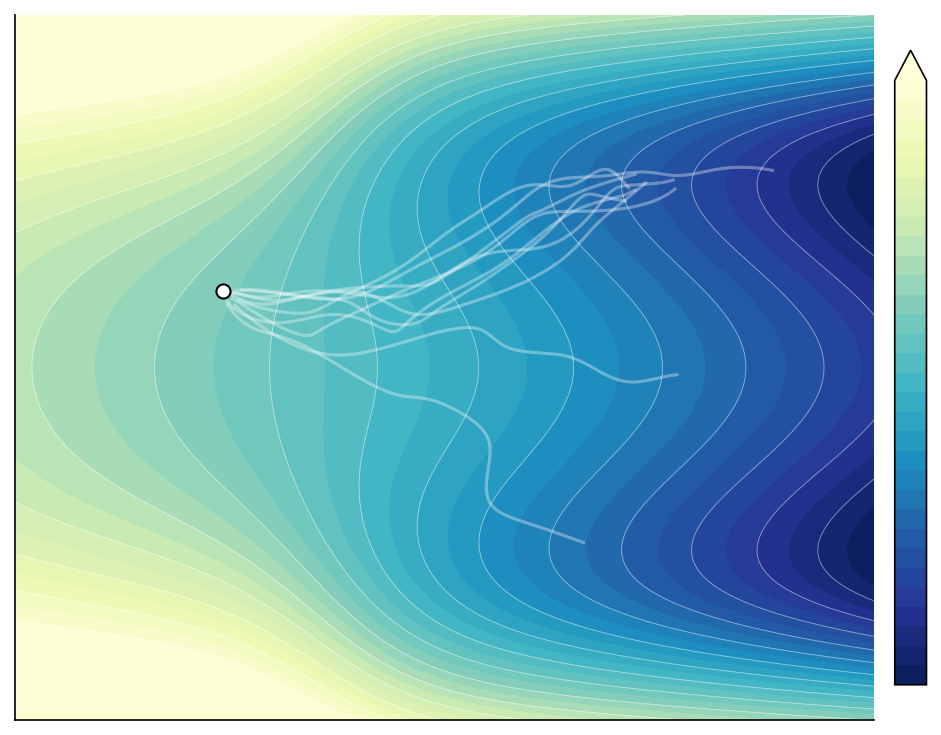

In [5]:

langevin = simulate_langevin_trajectories(surface, 
                                          start=START_POS, 
                                          n_trajectories=10, 
                                          n_steps=N_STEPS, 
                                          dt=DT, 
                                          diffusion=DIFFUSION, 
                                          mobility=MOBILITY, 
                                          smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA, 
                                          seed=8)
langevin["smoothed"].shape

fig, ax = plt.subplots(figsize=(7.2, 5.0))
levels = np.linspace(U_plot.min(), U_plot.max(), 32)
filled = ax.contourf(F1, F2, U_plot, levels=levels, cmap="YlGnBu_r", extend="max")
ax.contour(F1, F2, U_plot, levels=levels[::2], colors="white", linewidths=0.45, alpha=0.45)

trajectories = langevin["smoothed"]
for traj in trajectories:
    ax.plot(traj[:, 0], traj[:, 1], color="white", lw=1.5, alpha=0.34)

# final_branch = trajectories[:, -1, 1] >= 0
# for branch_mask in (final_branch, ~final_branch):
#     if branch_mask.sum() == 0:
#         continue
#     branch_mean = trajectories[branch_mask].mean(axis=0)
#     ax.plot(branch_mean[:, 0], branch_mean[:, 1], color="white", lw=3.0, solid_capstyle="round", zorder=5)
#     ax.plot(branch_mean[:, 0], branch_mean[:, 1], color="black", lw=1.1, alpha=0.75, solid_capstyle="round", zorder=6)
#     add_path_arrow(ax, branch_mean[:, 0], branch_mean[:, 1], idx=220)

ax.scatter(
    [langevin["params"]["start"][0]],
    [langevin["params"]["start"][1]],
    s=46,
    color="white",
    edgecolor="black",
    linewidth=1.0,
    zorder=8,
)

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
strip_plot_chrome(ax)
cbar = fig.colorbar(filled, ax=ax, pad=0.02, shrink=0.9)
strip_colorbar_chrome(cbar)

fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_langevin_trajectories.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "waddington_langevin_trajectories.pdf", bbox_inches="tight")
plt.show()


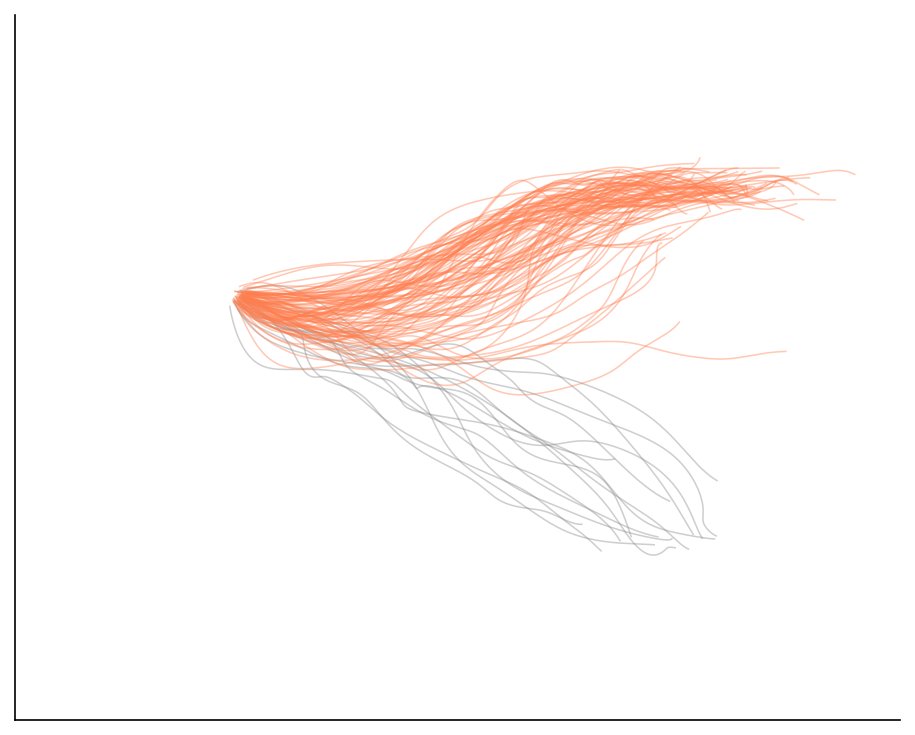

In [6]:
raw_ensemble = simulate_langevin_trajectories(
    surface,
    start=START_POS,
    n_trajectories=120,
    n_steps=N_STEPS,
    dt=DT,
    diffusion=DIFFUSION,
    mobility=MOBILITY,
    smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
    seed=11,
)

raw_trajectories = raw_ensemble["smoothed"]
basin_1 = raw_trajectories[:, -1, 1] < 0
basin_2 = ~basin_1
basin_colors = {"basin 1": "0.55", "basin 2": "coral"}

fig, ax = plt.subplots(figsize=(6.2, 5.0))
for basin_label, basin_mask in (("basin 1", basin_1), ("basin 2", basin_2)):
    for traj_idx, traj in enumerate(raw_trajectories[basin_mask]):
        ax.plot(
            traj[:, 0],
            traj[:, 1],
            color=basin_colors[basin_label],
            lw=0.75,
            alpha=0.42,
            label=basin_label if traj_idx == 0 else None,
        )

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
ax.legend(frameon=False, loc="upper left")
strip_plot_chrome(ax)
fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_langevin_raw_by_basin.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "waddington_langevin_raw_by_basin.pdf", bbox_inches="tight")
plt.show()


In [7]:
FIG_DIR

PosixPath('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/fishcaster')

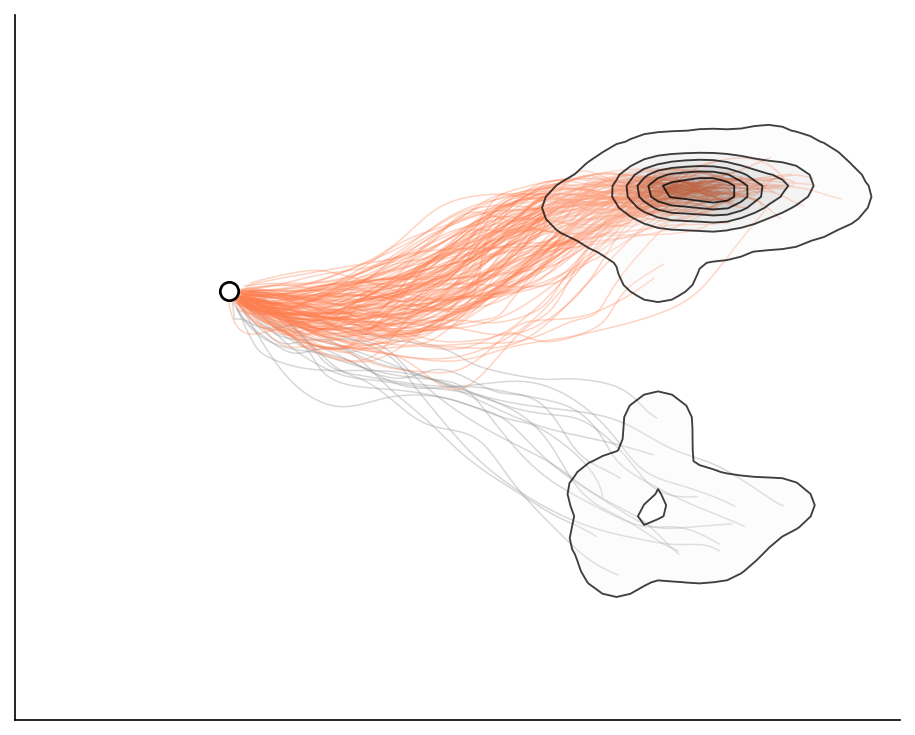

In [8]:
def smooth_density_grid(density, smoothing_sigma=1.4):
    if smoothing_sigma is None or smoothing_sigma <= 0:
        return density

    radius = max(1, int(np.ceil(3 * smoothing_sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / smoothing_sigma) ** 2)
    kernel /= kernel.sum()

    padded = np.pad(density, ((radius, radius), (0, 0)), mode="edge")
    smoothed = np.apply_along_axis(lambda vals: np.convolve(vals, kernel, mode="valid"), 0, padded)
    padded = np.pad(smoothed, ((0, 0), (radius, radius)), mode="edge")
    return np.apply_along_axis(lambda vals: np.convolve(vals, kernel, mode="valid"), 1, padded)


density_ensemble = simulate_langevin_trajectories(
    surface,
    start=START_POS,
    n_trajectories=150,
    n_steps=N_STEPS,
    dt=DT,
    diffusion=DIFFUSION,
    mobility=MOBILITY,
    smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
    seed=15,
)

density_trajectories = density_ensemble["smoothed"]
final_locations = density_trajectories[:, -1, :]
basin_1 = final_locations[:, 1] < 0
basin_2 = ~basin_1
basin_colors = {"basin 1": "0.55", "basin 2": "coral"}

hist, x_edges, y_edges = np.histogram2d(
    final_locations[:, 0],
    final_locations[:, 1],
    bins=64,
    range=[[F1.min(), F1.max()], [F2.min(), F2.max()]],
    density=True,
)
endpoint_density = smooth_density_grid(hist.T, smoothing_sigma=ENDPOINT_DENSITY_SMOOTHING_SIGMA)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
positive_density = endpoint_density[endpoint_density > 0]
density_levels = np.linspace(np.percentile(positive_density, 55), endpoint_density.max(), 7)

fig, ax = plt.subplots(figsize=(6.2, 5.0))
for basin_label, basin_mask in (("basin 1", basin_1), ("basin 2", basin_2)):
    for traj_idx, traj in enumerate(density_trajectories[basin_mask]):
        ax.plot(
            traj[:, 0],
            traj[:, 1],
            color=basin_colors[basin_label],
            lw=0.72,
            alpha=0.34,
            label=basin_label if traj_idx == 0 else None,
        )

ax.contourf(
    x_centers,
    y_centers,
    endpoint_density,
    levels=density_levels,
    cmap="Greys",
    alpha=0.28,
    zorder=4,
)
ax.contour(
    x_centers,
    y_centers,
    endpoint_density,
    levels=density_levels,
    colors="black",
    linewidths=0.9,
    alpha=0.75,
    zorder=5,
)

start = np.asarray(density_ensemble["params"]["start"])
ax.scatter(
    [start[0]],
    [start[1]],
    s=78,
    color="white",
    edgecolor="black",
    linewidth=1.3,
    zorder=8,
)

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
ax.legend(frameon=False, loc="upper left")
strip_plot_chrome(ax)
fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_langevin_endpoint_density.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "waddington_langevin_endpoint_density.pdf", bbox_inches="tight")
plt.show()


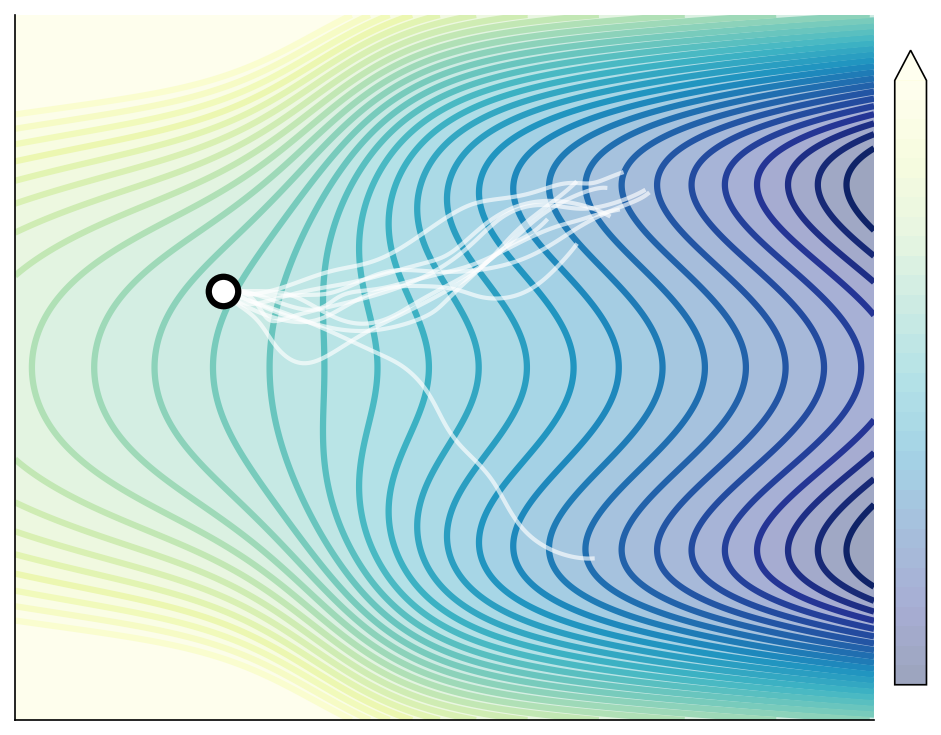

In [9]:
def add_terminal_arrow(ax, traj, color="black", alpha=0.45, step_back=8):
    """Draw a short arrow aligned to the leading tip of a trajectory."""
    if len(traj) < 2:
        return
    end_idx = len(traj) - 1
    start_idx = max(0, end_idx - step_back)
    while start_idx > 0 and np.allclose(traj[start_idx], traj[end_idx]):
        start_idx -= 1
    ax.annotate(
        "",
        xy=(traj[end_idx, 0], traj[end_idx, 1]),
        xytext=(traj[start_idx, 0], traj[start_idx, 1]),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=1.1,
            alpha=alpha,
            mutation_scale=8,
            shrinkA=0,
            shrinkB=0,
        ),
        zorder=6,
    )


variant_ensemble = simulate_langevin_trajectories(
    surface,
    start=START_POS,
    n_trajectories=10,
    n_steps=125, #N_STEPS,
    dt=DT,
    diffusion=DIFFUSION,
    mobility=MOBILITY,
    smoothing_sigma=TRAJECTORY_SMOOTHING_SIGMA,
    seed=81,
)
variant_trajectories = variant_ensemble["smoothed"]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
potential_cmap = plt.get_cmap("YlGnBu_r")
levels = np.linspace(U_plot.min(), U_plot.max(), 32)
filled = ax.contourf(
    F1,
    F2,
    U_plot,
    levels=levels,
    cmap=potential_cmap,
    extend="max",
    alpha=0.4,
)
ax.contour(
    F1,
    F2,
    U_plot,
    levels=levels,#[::2],
    # colors="black",
    cmap=potential_cmap,
    linewidths=3,
    alpha=1,
)

for traj in variant_trajectories:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        color="white",
        lw=2,
        alpha=0.65,
        zorder=5,
    )
    # add_terminal_arrow(ax, traj, color="black", alpha=0.5, step_back=8)

start = np.asarray(variant_ensemble["params"]["start"])
ax.scatter(
    [start[0]],
    [start[1]],
    s=200,
    color="white",
    edgecolor="black",
    linewidth=3,
    zorder=8,
)

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
strip_plot_chrome(ax)
cbar = fig.colorbar(filled, ax=ax, pad=0.02, shrink=0.9)
strip_colorbar_chrome(cbar)
fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_langevin_trajectories_contourline_variant.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "waddington_langevin_trajectories_contourline_variant.pdf", bbox_inches="tight")
plt.show()


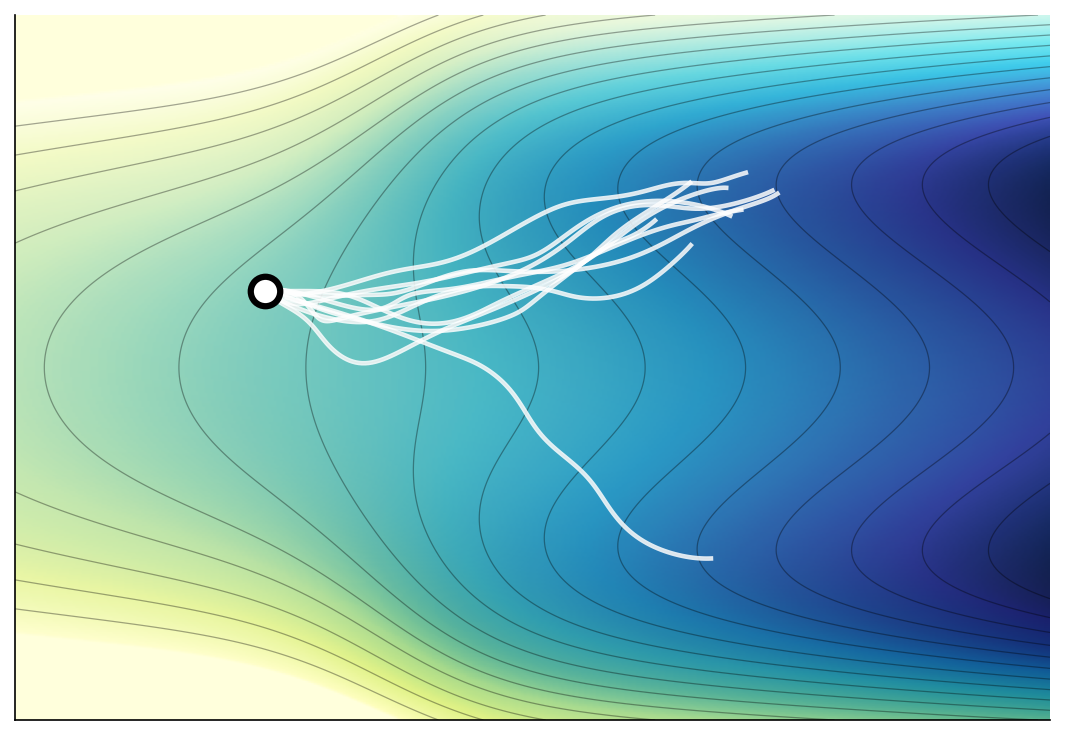

In [10]:
from matplotlib.colors import LightSource, Normalize
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7.2, 5.0))

# Normalize display-compressed potential for shading/color
U_hillshade = U_plot
norm = Normalize(vmin=U_hillshade.min(), vmax=U_hillshade.max())

# Create hillshade
ls = LightSource(azdeg=315, altdeg=35)
rgb = ls.shade(
    U_hillshade,
    cmap=plt.get_cmap("YlGnBu_r"),
    norm=norm,
    vert_exag=0.45,
    blend_mode="soft",
)

ax.imshow(
    rgb,
    extent=[F1.min(), F1.max(), F2.min(), F2.max()],
    origin="lower",
    aspect="auto",
    alpha=0.95,
    zorder=0,
)

# Add thin contours on top
levels = np.linspace(U_plot.min(), U_plot.max(), 18)
ax.contour(
    F1,
    F2,
    U_plot,
    levels=levels,
    colors="black",
    linewidths=0.6,
    alpha=0.35,
    zorder=2,
)

# Trajectories
for traj in variant_trajectories:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        color="white",
        lw=2.2,
        alpha=0.85,
        zorder=5,
    )
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        color="black",
        lw=0.6,
        alpha=0.35,
        zorder=4,
    )
    # add_terminal_arrow(ax, traj, color="white", alpha=0.85, step_back=8)

# Start point
start = np.asarray(variant_ensemble["params"]["start"])
ax.scatter(
    [start[0]],
    [start[1]],
    s=200,
    color="white",
    edgecolor="black",
    linewidth=3,
    zorder=8,
)

ax.set(xlim=(F1.min(), F1.max()), ylim=(F2.min(), F2.max()))
strip_plot_chrome(ax)

fig.tight_layout()
fig.savefig(FIG_DIR / "waddington_langevin_trajectories_hillshade.png", bbox_inches="tight", dpi=300)
fig.savefig(FIG_DIR / "waddington_langevin_trajectories_hillshade.pdf", bbox_inches="tight")
plt.show()

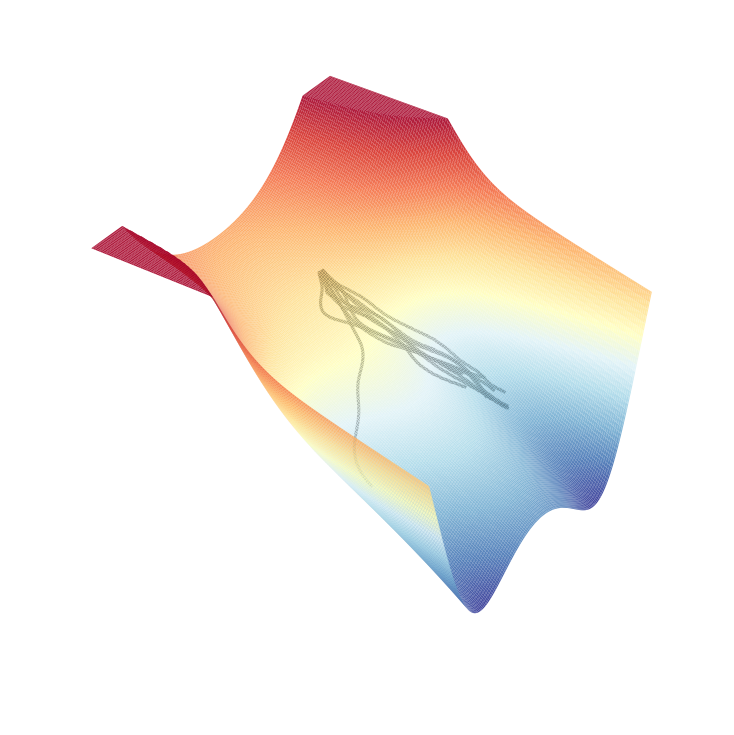

In [11]:
fig = plt.figure(figsize=(7.2, 5.0))
ax = fig.add_subplot(111, projection="3d")
Z_plot = U_plot

ax.plot_surface(
    F1,
    F2,
    Z_plot,
    cmap="RdYlBu_r",
    linewidth=0,
    antialiased=True,
    alpha=0.9,
    rstride=2,
    cstride=2,
)

for traj in variant_trajectories:
    # Interpolate approximate U values along trajectory
    # Simple nearest-neighbor version
    ix = np.searchsorted(F1[0, :], traj[:, 0]).clip(0, F1.shape[1] - 1)
    iy = np.searchsorted(F2[:, 0], traj[:, 1]).clip(0, F2.shape[0] - 1)
    z = Z_plot[iy, ix] + 0.02 * np.ptp(Z_plot)

    ax.plot(
        traj[:, 0],
        traj[:, 1],
        z,
        color="black",
        lw=1.5,
        alpha=0.8,
    )

ax.view_init(elev=35, azim=-55)
ax.set_axis_off()

fig.tight_layout()
plt.show()

In [12]:
filled = ax.contourf(
    F1,
    F2,
    U_plot,
    levels=levels,
    cmap="RdYlBu_r",
    extend="max",
    alpha=0.75,
)

ax.contour(
    F1,
    F2,
    U_plot,
    levels=levels[::2],
    colors="black",
    linewidths=0.5,
    alpha=0.35,
)
